In [6]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Import Functions**

In [2]:
# travel_mining_clean.py
# Revised, robust pipeline for your uploaded CSV
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from mlxtend.frequent_patterns import apriori, association_rules


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **Uploading and Loading the Dataset**

In [4]:


from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    FILE_PATH = fn
    print("Uploaded file:", FILE_PATH)

df = pd.read_csv(FILE_PATH)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving Worldwide Travel Cities Dataset (Ratings and Climate).csv to Worldwide Travel Cities Dataset (Ratings and Climate).csv
Uploaded file: Worldwide Travel Cities Dataset (Ratings and Climate).csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **Essential Rows Needed**

In [5]:
print("✅ Loaded file:", FILE_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample rows:")
print(df.head(5).T)

✅ Loaded file: Worldwide Travel Cities Dataset (Ratings and Climate).csv
Shape: (560, 19)
Columns: ['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']

Sample rows:
                                                                   0  \
id                              c54acf38-3029-496b-8c7a-8343ad82785c   
city                                                           Milan   
country                                                        Italy   
region                                                        europe   
short_description  Chic streets lined with fashion boutiques, his...   
latitude                                                   45.464194   
longitude                                                   9.189635   
avg_temp_monthly   {"1":{"avg":3.7,"max":7.8,"min":0.4},"2":{"avg...   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **Parsing and Cleaning the Dataset**

In [7]:

def parse_avg_temp_monthly(val):
    if pd.isna(val): return np.nan
    try: d = json.loads(val)
    except:
        try: d = ast.literal_eval(val)
        except: return np.nan
    avgs = []
    for _, v in d.items():
        if isinstance(v, dict) and "avg" in v:
            try: avgs.append(float(v["avg"]))
            except: pass
        else:
            try: avgs.append(float(v))
            except: pass
    return np.mean(avgs) if avgs else np.nan

if 'avg_temp_monthly' in df.columns:
    df['avg_annual_temp'] = df['avg_temp_monthly'].apply(parse_avg_temp_monthly)

def parse_list_like(val):
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list): return [str(x).strip() for x in parsed]
        return [str(parsed)]
    except:
        s2 = str(val).strip("[]")
        return [i.strip().strip('\'"') for i in s2.split(',') if i.strip()]

if 'ideal_durations' in df.columns:
    df['ideal_durations_list'] = df['ideal_durations'].apply(parse_list_like)
    all_durations = set(d for sub in df['ideal_durations_list'] for d in sub)
    for dur in sorted(all_durations):
        df[f"dur_{dur.replace(' ', '_')}"] = df['ideal_durations_list'].apply(lambda lst: int(dur in lst))

# **Basic Cleaning of the dataset**

In [12]:

rating_cols = [c for c in ['culture','adventure','nature','beaches','nightlife',
                           'cuisine','wellness','urban','seclusion'] if c in df.columns]

for c in rating_cols:
    df[c] = df[c].fillna(df[c].median())

if 'avg_annual_temp' in df.columns:
    df['avg_annual_temp'] = df['avg_annual_temp'].fillna(df['avg_annual_temp'].median())

if 'budget_level' in df.columns:
    df['budget_level'] = df['budget_level'].fillna("Unknown")


# **Feature Engineering Techniques**

In [13]:

df['overall_score'] = df[rating_cols].mean(axis=1) if rating_cols else 0.0



# **Clustering**


Cluster counts:
 cluster
0    265
1    150
2    145
Name: count, dtype: int64


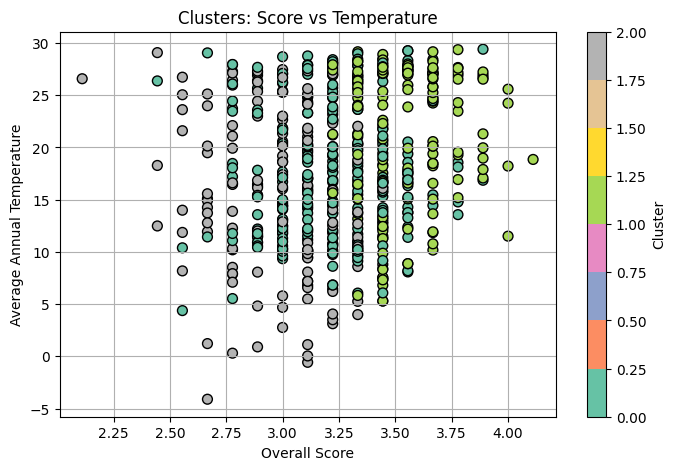

In [14]:


cluster_features = ['overall_score'] + [c for c in ['avg_annual_temp'] if c in df.columns] + rating_cols
X_cluster = df[cluster_features].copy().fillna(df[cluster_features].median())

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)
print("\nCluster counts:\n", df['cluster'].value_counts())

plt.figure(figsize=(8,5))
if 'avg_annual_temp' in cluster_features:
    plt.scatter(df['overall_score'], df['avg_annual_temp'],
                c=df['cluster'], cmap='Set2', s=50, edgecolor='k')
    plt.xlabel('Overall Score')
    plt.ylabel('Average Annual Temperature')
    plt.title('Clusters: Score vs Temperature')
else:
    plt.scatter(df['overall_score'], df['overall_score'],
                c=df['cluster'], cmap='Set2', s=50, edgecolor='k')
    plt.xlabel('Overall Score')
    plt.title('Clusters (Score)')
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

# **Classification**

In [15]:

TARGET = 'budget_level'
feature_cols = rating_cols.copy()
if 'avg_annual_temp' in df.columns: feature_cols.append('avg_annual_temp')
feature_cols += [c for c in df.columns if c.startswith('dur_')]
for c in ['latitude','longitude']:
    if c in df.columns: feature_cols.append(c)

X, y = df[feature_cols], df[TARGET]
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.3, random_state=42, stratify=y_enc)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_target.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))




Classification Accuracy: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

      Budget       0.63      0.67      0.65        43
      Luxury       0.78      0.30      0.44        23
   Mid-range       0.74      0.82      0.78       102

    accuracy                           0.71       168
   macro avg       0.72      0.60      0.62       168
weighted avg       0.72      0.71      0.70       168


Confusion Matrix:
 [[29  0 14]
 [ 1  7 15]
 [16  2 84]]


# **Heatmap Visualization**

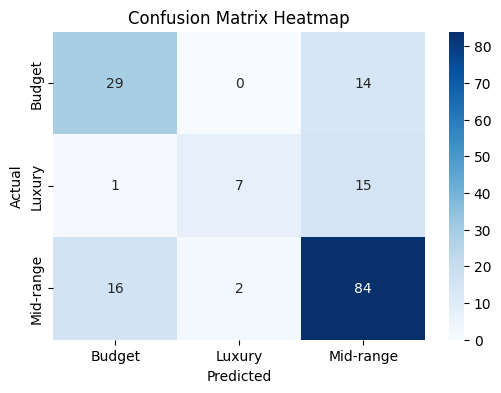

In [16]:

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# **Association Rules**


Top Association Rules:

Rule: dur_Day_trip_0, dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1, dur_Day_trip_0 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1, dur_One_week_1 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_One_week_1, dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_One_week_1, dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1, dur_Day_trip_0 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1, dur_One_week_1, dur_Day_trip_0 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Day_trip_0, dur_One_week_1, dur_Weekend_0, budget_level_Luxury  →  dur_Long_trip_1 (support=0.05, conf=0.60, lift=6.29)
Rule: dur_Day_trip_0, dur_Weeke

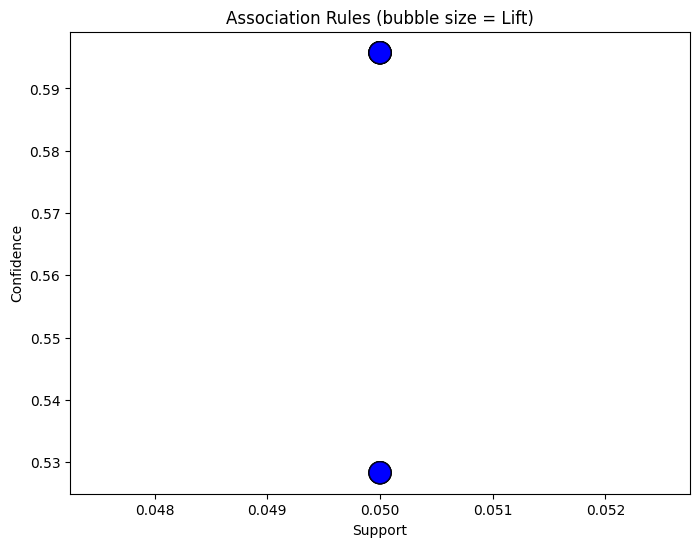


💾 Saved top rules to association_rules.csv

✅ Script finished.


In [17]:

basket = pd.DataFrame()
basket['budget_level'] = df['budget_level'].astype(str)
if 'country' in df.columns: basket['country'] = df['country'].astype(str)
for c in [c for c in df.columns if c.startswith('dur_')]:
    basket[c] = df[c].astype(int)

basket_encoded = pd.get_dummies(basket.astype(str))

frequent_itemsets = apriori(basket_encoded, min_support=0.05, use_colnames=True)
if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    if not rules.empty:
        rules_sorted = rules.sort_values(by='lift', ascending=False).head(15)
        print("\nTop Association Rules:\n")
        for _, row in rules_sorted.iterrows():
            ant = ", ".join(list(row['antecedents']))
            cons = ", ".join(list(row['consequents']))
            print(f"Rule: {ant}  →  {cons} "
                  f"(support={row['support']:.2f}, conf={row['confidence']:.2f}, lift={row['lift']:.2f})")

        # Bubble chart
        plt.figure(figsize=(8,6))
        plt.scatter(rules_sorted['support'], rules_sorted['confidence'],
                    s=rules_sorted['lift']*40, alpha=0.6, c='blue', edgecolors="k")
        plt.xlabel("Support")
        plt.ylabel("Confidence")
        plt.title("Association Rules (bubble size = Lift)")
        plt.show()

        # Save rules
        rules_sorted.to_csv("association_rules.csv", index=False)
        print("\n💾 Saved top rules to association_rules.csv")
    else:
        print("No association rules found.")
else:
    print("No frequent itemsets found (try lowering min_support).")

print("\n✅ Script finished.")